# Review моделей CatBoost

Этот ноутбук загружает модели из `data/profile_model.pkl` и `data/fault_model.pkl`,
выводит ключевые метрики обучения, строит графики обучения и показывает feature importance.

In [3]:
import os
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import joblib
except Exception:
    joblib = None

try:
    import catboost as cb
except Exception as e:
    cb = None
    print("CatBoost не импортирован: ", e)

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

PROFILE_PATH = "/home/daniil_gorenkov/dissertation/Dissertation/data/profile_model.pkl"
FAULT_PATH = "/home/daniil_gorenkov/dissertation/Dissertation/data/fault_model.pkl"

def load_model(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл модели: {path}")
    if joblib is not None:
        try:
            return joblib.load(path)
        except Exception:
            pass
    with open(path, "rb") as f:
        return pickle.load(f)

profile_model = load_model(Path(PROFILE_PATH))
fault_model = load_model(Path(FAULT_PATH))

print("Загружены модели:")
print("- profile_model:", type(profile_model))
print("- fault_model:", type(fault_model))

Загружены модели:
- profile_model: <class 'catboost.core.CatBoostClassifier'>
- fault_model: <class 'catboost.core.CatBoostClassifier'>


In [4]:
def summarize_model(model, name: str):
    print("=" * 80)
    print(f"Модель: {name}")
    print("=" * 80)

    try:
        print("Параметры модели:")
        print(model.get_params())
    except Exception:
        print("Параметры недоступны.")

    try:
        print("Best score:")
        print(model.get_best_score())
    except Exception:
        print("Best score недоступен.")

    try:
        print("Best iteration:", model.get_best_iteration())
    except Exception:
        print("Best iteration недоступен.")

    try:
        print("Tree count:", model.tree_count_)
    except Exception:
        pass

summarize_model(profile_model, "profile_model")
summarize_model(fault_model, "fault_model")

Модель: profile_model
Параметры модели:
{'iterations': 5000, 'learning_rate': 0.13211202488090648, 'depth': 5, 'l2_leaf_reg': 9.43485032895685, 'border_count': 171, 'od_wait': 100, 'od_type': 'Iter', 'random_seed': 101, 'random_strength': 0.7151665545857637, 'bagging_temperature': 0.11412417323963553, 'task_type': 'GPU'}
Best score:
{'learn': {'MultiClass': 0.2894789576675855}, 'validation': {'MultiClass': 0.463982433118475}}
Best iteration: 4999
Tree count: 5000
Модель: fault_model
Параметры модели:
{'iterations': 5000, 'learning_rate': 0.2689777123362394, 'depth': 3, 'l2_leaf_reg': 9.523826971416215, 'border_count': 230, 'od_wait': 100, 'od_type': 'Iter', 'random_seed': 101, 'random_strength': 0.5632573376683527, 'bagging_temperature': 0.41075176991945006, 'task_type': 'GPU'}
Best score:
{'learn': {'Logloss': 0.08241394924356349}, 'validation': {'Logloss': 0.12371031318614684}}
Best iteration: 1763
Tree count: 1764


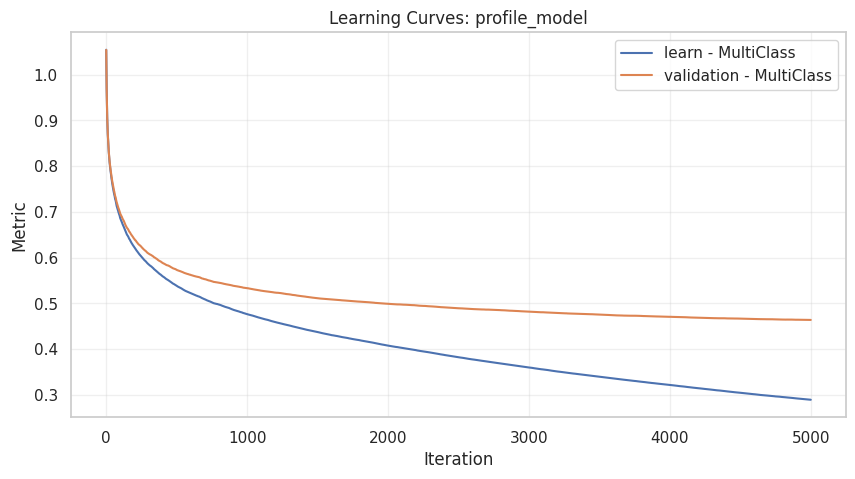

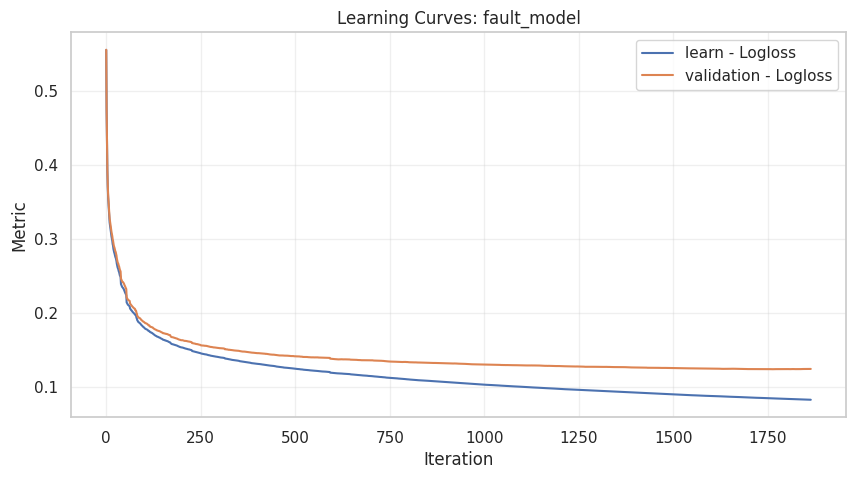

In [5]:
def plot_learning_curves(model, name: str):
    try:
        evals = model.get_evals_result()
    except Exception:
        evals = None

    if not evals:
        print(f"Нет evals_result для {name}. Графики обучения недоступны.")
        return

    plt.figure(figsize=(10, 5))
    for dataset_name, metrics in evals.items():
        for metric_name, values in metrics.items():
            plt.plot(values, label=f"{dataset_name} - {metric_name}")
    plt.title(f"Learning Curves: {name}")
    plt.xlabel("Iteration")
    plt.ylabel("Metric")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_learning_curves(profile_model, "profile_model")
plot_learning_curves(fault_model, "fault_model")

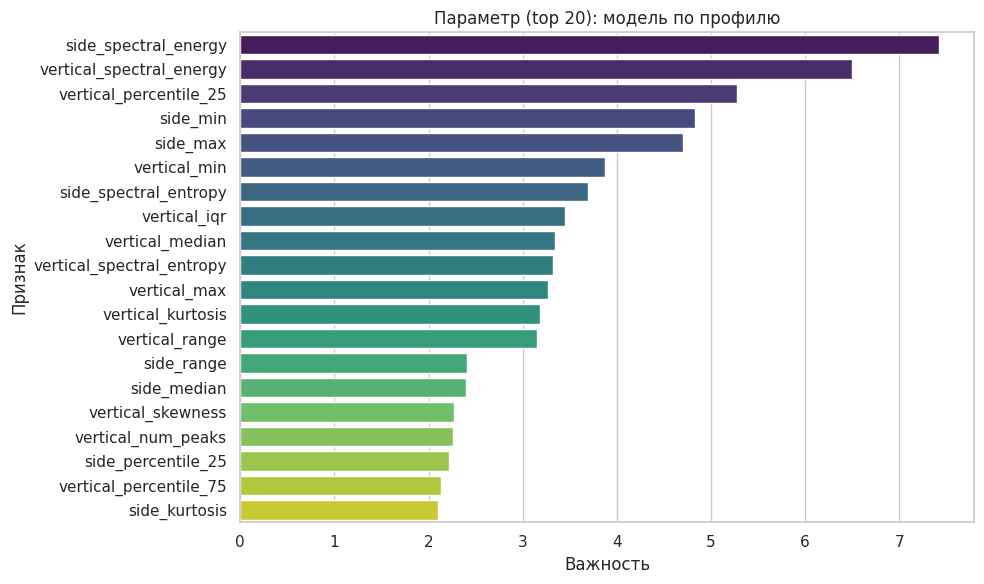

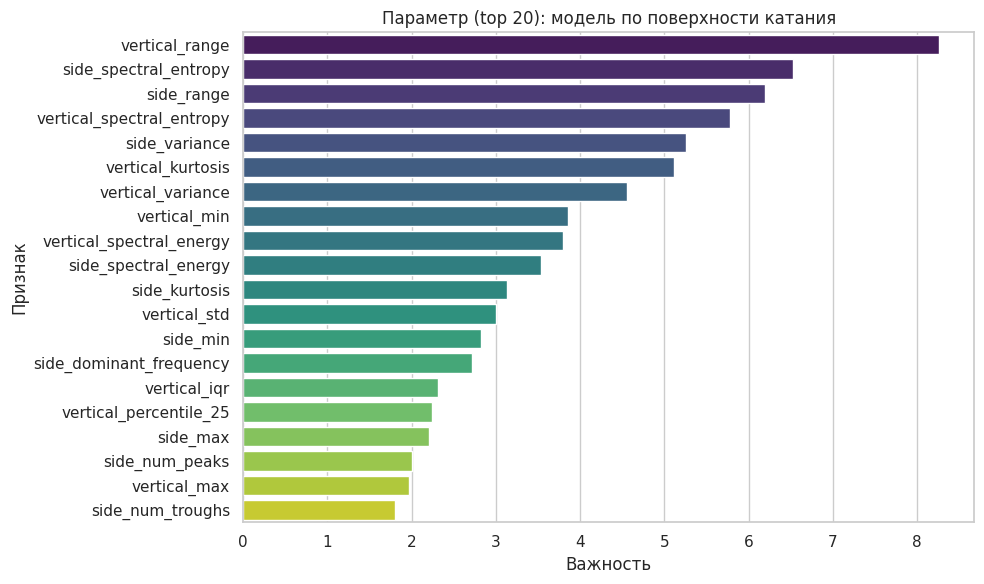

In [16]:
def plot_feature_importance(model, name: str, top_n: int = 20):
    try:
        fi = model.get_feature_importance(prettified=True)
        if isinstance(fi, pd.DataFrame) and {"Feature Id", "Importances"}.issubset(fi.columns):
            df = fi.rename(columns={"Feature Id": "feature", "Importances": "importance"})
        else:
            raise ValueError("Unexpected format")
    except Exception:
        try:
            importances = model.get_feature_importance()
            feature_names = getattr(model, "feature_names_", None)
            if feature_names is None:
                feature_names = [f"f{i}" for i in range(len(importances))]
            df = pd.DataFrame({"feature": feature_names, "importance": importances})
        except Exception:
            print(f"Не удалось получить feature importance для {name}.")
            return

    df = df.sort_values("importance", ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="importance", y="feature", palette="viridis")
    plt.title(f"Параметр (top {top_n}): {name}")
    plt.xlabel("Важность")
    plt.ylabel("Признак")
    plt.tight_layout()
    plt.show()

plot_feature_importance(profile_model, "модель по профилю")
plot_feature_importance(fault_model, "модель по поверхности катания")

## Дополнительная оценка на тестовых данных (опционально)

Если доступны тестовые данные, можно вычислить метрики качества.

In [7]:
import pickle
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load datasets
with open("/home/daniil_gorenkov/dissertation/Dissertation/data/fault_target_dataset.pkl", 'rb') as f:
    fault_dataset = pickle.load(f)

with open("/home/daniil_gorenkov/dissertation/Dissertation/data/profile_target_dataset.pkl", 'rb') as f:
    profile_dataset = pickle.load(f)

# Extract test sets
x_test_fault, y_test_fault = fault_dataset['X_test'], fault_dataset['y_test']
x_test_profile, y_test_profile = profile_dataset['X_test'], profile_dataset['y_test']

# Make predictions
fault_predictions = fault_model.predict(x_test_fault)
profile_predictions = profile_model.predict(x_test_profile)

# Calculate metrics

fault_accuracy = accuracy_score(y_test_fault, fault_predictions)
profile_accuracy = accuracy_score(y_test_profile, profile_predictions)

print(f"Fault Model Accuracy: {fault_accuracy:.4f}")
print(f"Profile Model Accuracy: {profile_accuracy:.4f}")

Fault Model Accuracy: 0.9492
Profile Model Accuracy: 0.8026


In [8]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error

def evaluate_model(model, name: str, X_test, y_test):
    preds = model.predict(X_test)
    print("=" * 80)
    print(f"Метрики для {name}")
    print("=" * 80)

    is_regression = np.issubdtype(y_test.dtype, np.floating) and len(np.unique(y_test)) > 20
    if is_regression:
        rmse = mean_squared_error(y_test, preds, squared=False)
        print(f"RMSE: {rmse:.4f}")
    else:
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="weighted")
        print(f"Accuracy: {acc:.4f}")
        print(f"F1 (weighted): {f1:.4f}")
        if len(np.unique(y_test)) == 2:
            try:
                proba = model.predict_proba(X_test)[:, 1]
                auc = roc_auc_score(y_test, proba)
                print(f"ROC-AUC: {auc:.4f}")
            except Exception:
                pass

# Раскомментируйте для оценки на тестовых данных
evaluate_model(profile_model, "profile_model", x_test_profile, y_test_profile)
evaluate_model(fault_model, "fault_model", x_test_fault, y_test_fault)

Метрики для profile_model
Accuracy: 0.8026
F1 (weighted): 0.8017
Метрики для fault_model
Accuracy: 0.9492
F1 (weighted): 0.9492
ROC-AUC: 0.9912


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# Функция для вывода метрик классификации
def print_classification_metrics(y_true, y_pred, model_name: str):
    print(f"\n{'='*80}")
    print(f"МЕТРИКИ КЛАССИФИКАЦИИ: {model_name}")
    print(f"{'='*80}\n")
    print(classification_report(y_true, y_pred, digits=4))

# Функция для рисования confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y_true), 
                yticklabels=np.unique(y_true))
    plt.title(f'Матрица ошибок: {model_name}')
    plt.ylabel('Истинная метка')
    plt.xlabel('Предсказанная метка')
    plt.tight_layout()
    plt.show()

# Функция для ROC-AUC кривой
def plot_roc_curve(y_true, y_pred_proba, model_name: str):
    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Кривая: {model_name}')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"ROC curve недоступна для многоклассовой классификации в {model_name}")

# Функция для Precision-Recall кривой
def plot_precision_recall_curve(y_true, y_pred_proba, model_name: str):
    if len(np.unique(y_true)) == 2:
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        
        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, color='blue', lw=2)
        plt.fill_between(recall, precision, alpha=0.2)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve: {model_name}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Precision-Recall curve недоступна для многоклассовой классификации в {model_name}")

# Функция для сравнения распределения предсказаний
def plot_prediction_distribution(y_pred, model_name: str):
    plt.figure(figsize=(10, 5))
    unique_classes = np.unique(y_pred)
    counts = [np.sum(y_pred == c) for c in unique_classes]
    plt.bar(unique_classes, counts, color='skyblue', edgecolor='black')
    plt.xlabel('Predicted Class')
    plt.ylabel('Count')
    plt.title(f'Distribution of Predictions: {model_name}')
    plt.xticks(unique_classes)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print("Функции для визуализации метрик загружены успешно!")

Функции для визуализации метрик загружены успешно!


ROC curve недоступна для многоклассовой классификации в profile_model


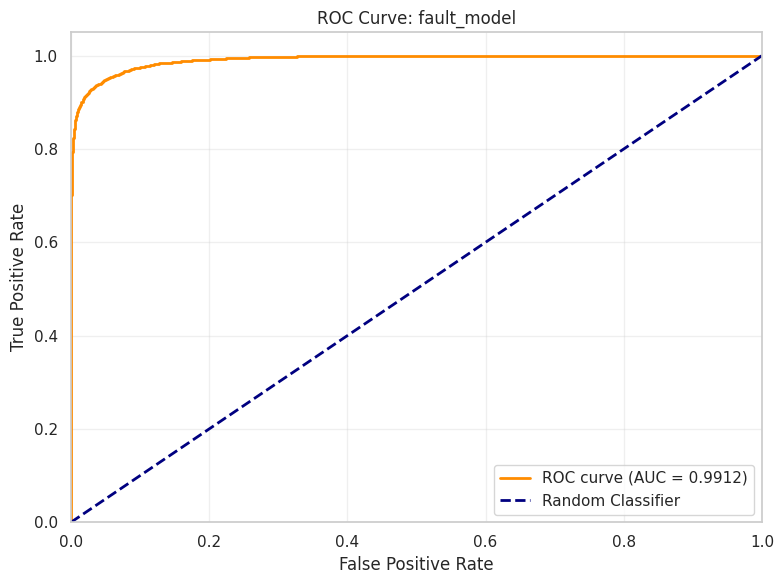

In [10]:
# Пример использования ROC кривой
# Загрузите X_test и y_test, затем раскомментируйте и запустите

y_pred_profile = profile_model.predict(x_test_profile)
y_pred_proba_profile = profile_model.predict_proba(x_test_profile)[:, 1]

y_pred_fault = fault_model.predict(x_test_fault)
y_pred_proba_fault = fault_model.predict_proba(x_test_fault)[:, 1]

# ROC кривые для обеих моделей
plot_roc_curve(y_test_profile, y_pred_proba_profile, "profile_model")
plot_roc_curve(y_test_fault, y_pred_proba_fault, "fault_model")

# Сравнение на одном графике
if len(np.unique(y_test_profile)) == 2:
    fpr_profile, tpr_profile, _ = roc_curve(y_test_profile, y_pred_proba_profile)
    roc_auc_profile = auc(fpr_profile, tpr_profile)
    
    fpr_fault, tpr_fault, _ = roc_curve(y_test_fault, y_pred_proba_fault)
    roc_auc_fault = auc(fpr_fault, tpr_fault)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_profile, tpr_profile, color='blue', lw=2, label=f'Profile Model (AUC = {roc_auc_profile:.4f})')
    plt.plot(fpr_fault, tpr_fault, color='red', lw=2, label=f'Fault Model (AUC = {roc_auc_fault:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison: profile_model vs fault_model')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


PROFILE MODEL - ПОЛНЫЙ АНАЛИЗ

МЕТРИКИ КЛАССИФИКАЦИИ: модель по профилю

              precision    recall  f1-score   support

           0     0.8511    0.8975    0.8737      3425
           1     0.7654    0.7553    0.7603      3412
           2     0.7875    0.7547    0.7707      3412

    accuracy                         0.8026     10249
   macro avg     0.8013    0.8025    0.8016     10249
weighted avg     0.8014    0.8026    0.8017     10249



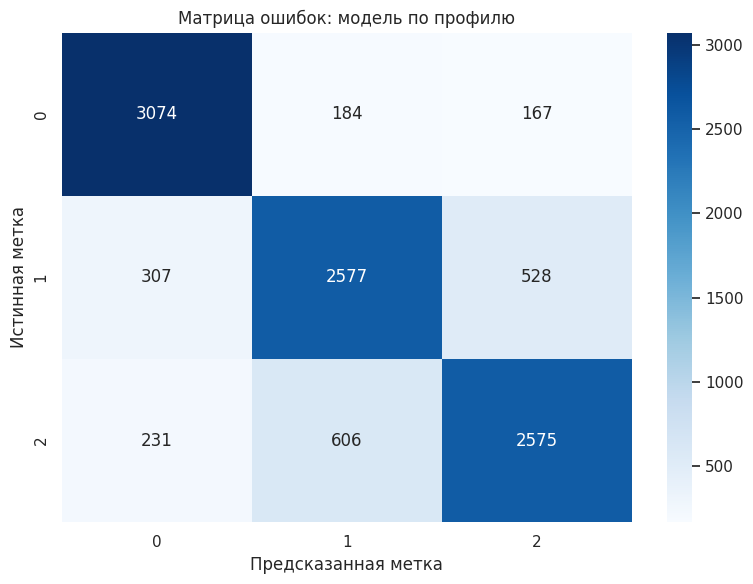

ROC curve недоступна для многоклассовой классификации в модель по профилю
Precision-Recall curve недоступна для многоклассовой классификации в модель по профилю


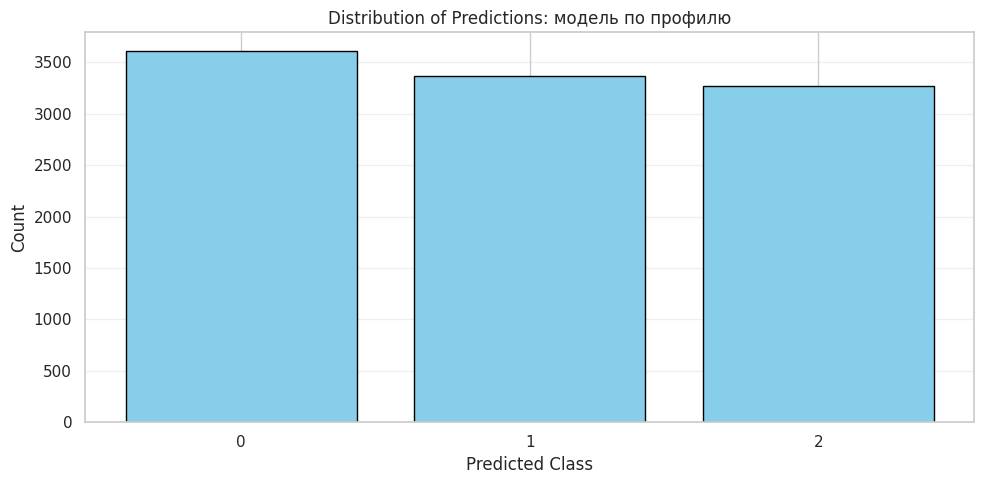

In [19]:
# Полные метрики для profile_model
print("\n" + "="*80)
print("PROFILE MODEL - ПОЛНЫЙ АНАЛИЗ")
print("="*80)

# Раскомментируй если есть X_test и y_test:
y_pred_profile = profile_model.predict(x_test_profile)
y_pred_proba_profile = profile_model.predict_proba(x_test_profile)[:, 1]

print_classification_metrics(y_test_profile, y_pred_profile, "модель по профилю")
plot_confusion_matrix(y_test_profile, y_pred_profile, "модель по профилю")
plot_roc_curve(y_test_profile, y_pred_proba_profile, "модель по профилю")
plot_precision_recall_curve(y_test_profile, y_pred_proba_profile, "модель по профилю")
plot_prediction_distribution(y_pred_profile, "модель по профилю")


FAULT MODEL - ПОЛНЫЙ АНАЛИЗ

МЕТРИКИ КЛАССИФИКАЦИИ: модель по поверхности катания

              precision    recall  f1-score   support

           0     0.9478    0.9518    0.9498      6181
           1     0.9506    0.9465    0.9486      6059

    accuracy                         0.9492     12240
   macro avg     0.9492    0.9492    0.9492     12240
weighted avg     0.9492    0.9492    0.9492     12240



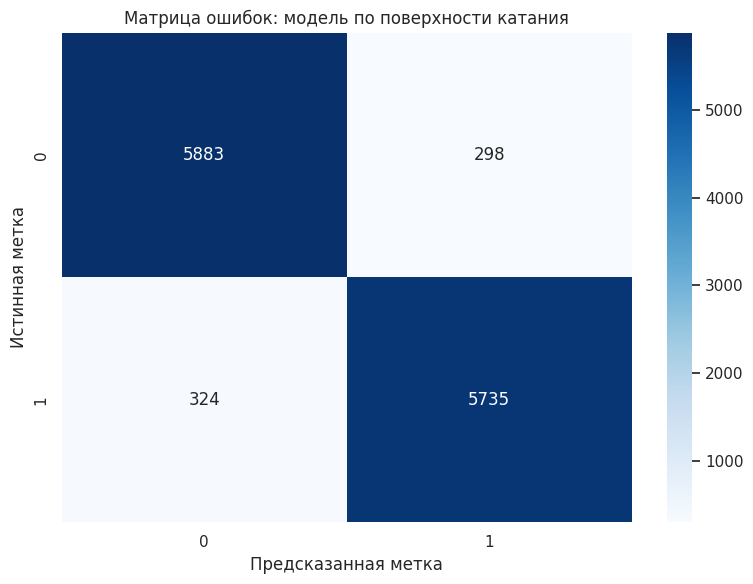

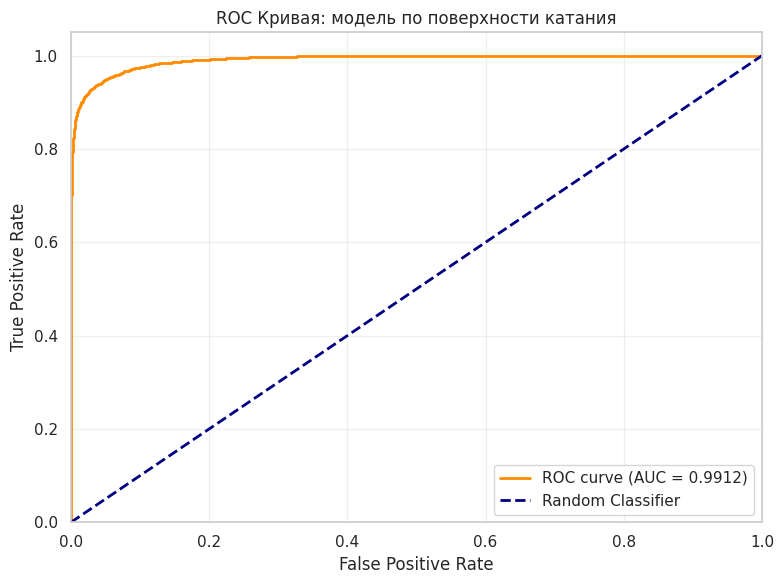

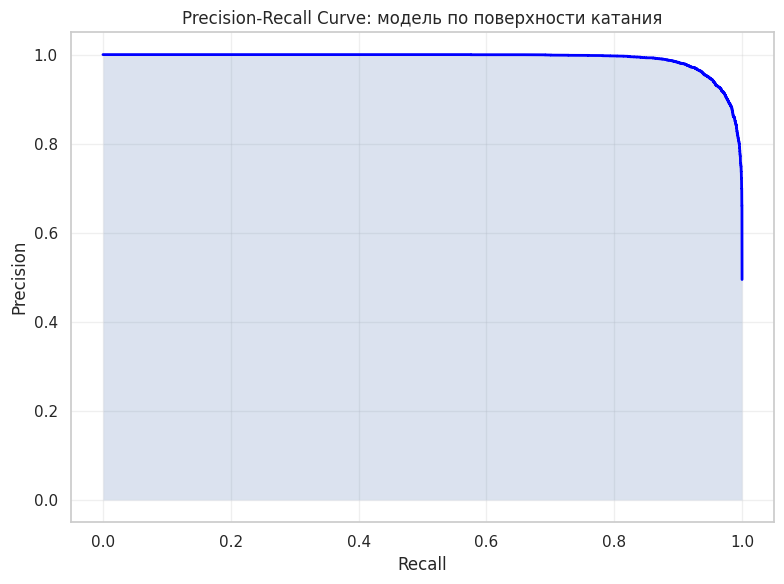

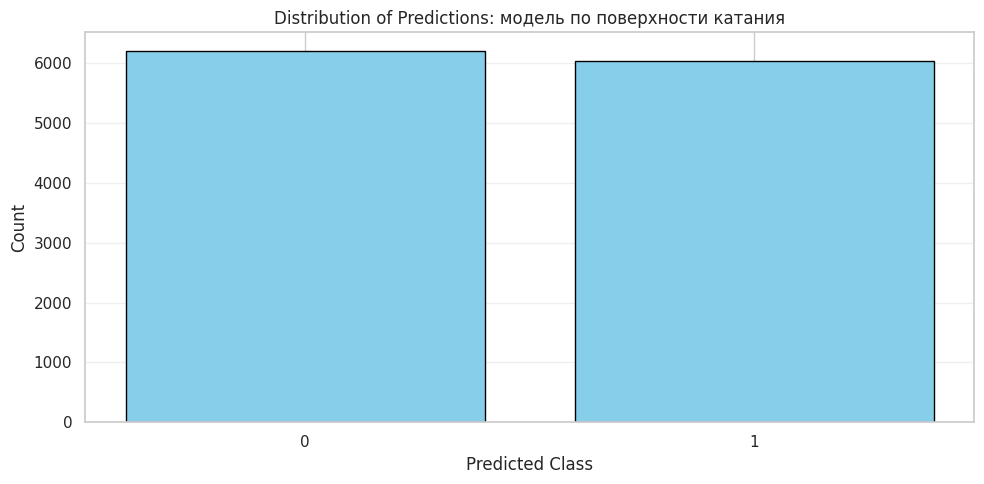

In [ ]:
# Полные метрики для fault_model
print("\n" + "="*80)
print("FAULT MODEL - ПОЛНЫЙ АНАЛИЗ")
print("="*80)

# Раскомментируй если есть X_test и y_test:
y_pred_fault = fault_model.predict(x_test_fault)
y_pred_proba_fault = fault_model.predict_proba(x_test_fault)[:, 1]

print_classification_metrics(y_test_fault, y_pred_fault, "модель по поверхности катания")
plot_confusion_matrix(y_test_fault, y_pred_fault, "модель по поверхности катания")
plot_roc_curve(y_test_fault, y_pred_proba_fault, "модель по поверхности катания")
plot_precision_recall_curve(y_test_fault, y_pred_proba_fault, "модель по поверхности катания")
plot_prediction_distribution(y_pred_fault, "модель по поверхности катания")

In [13]:
# Сравнение обеих моделей на одном графике
print("\n" + "="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*80)

# Раскомментируй для визуализации ROC кривых обеих моделей:
if len(np.unique(y_test_profile)) == 2:
    fpr_profile, tpr_profile, _ = roc_curve(y_test_profile, y_pred_proba_profile)
    roc_auc_profile = auc(fpr_profile, tpr_profile)
    
    fpr_fault, tpr_fault, _ = roc_curve(y_test_fault, y_pred_proba_fault)
    roc_auc_fault = auc(fpr_fault, tpr_fault)
    
    plt.figure(figsize=(12, 8))
    plt.plot(fpr_profile, tpr_profile, color='blue', lw=2.5, label=f'Profile Model (AUC = {roc_auc_profile:.4f})')
    plt.plot(fpr_fault, tpr_fault, color='red', lw=2.5, label=f'Fault Model (AUC = {roc_auc_fault:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves Comparison: profile_model vs fault_model', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nProfile Model AUC: {roc_auc_profile:.4f}")
    print(f"Fault Model AUC: {roc_auc_fault:.4f}")
    print(f"Разница: {abs(roc_auc_profile - roc_auc_fault):.4f}")


СРАВНЕНИЕ МОДЕЛЕЙ
